Author: Daniel Abadjiev (with some code taken from Eliza Howard)  
Date: November 3, 2025  
Description: First pass at starting on the cut-based analysis  
Based on /home/dabadjiev/smartpixels_ml_dsabadjiev/smartpixML/reGenBIB/MuonColliderSim/plotting_clusters_Daniel.ipynb   

In [1]:
import numpy as np 
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt                               
import os 
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
matplotlib.rcParams["figure.dpi"] = 150
from particle import PDGID
import sys
sys.path.append("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/")
from plotUtils import *

In [2]:
flp = 0
# trackHeader = ["cota", "cotb", "p", "flp", "ylocal", "zglobal", "pt", "t", "hit_pdg"]
dataDir_mm = "/local/d1/smartpixML/bigData/SimOutput_0730_bigPPt_mm/"
dataDir_mp = "/local/d1/smartpixML/bigData/SimOutput_0730_bigPPt_mp/"
dataDir_sig = "/local/d1/smartpixML/bigData/Simulation_Output_Signal/"
dataDir_all = "/local/d1/smartpixML/bigData/allData/"


In [3]:

skip_indices = list(range(1730 - 124+87, 1769))  # 1606+87 [hand-tuned the 87] to 1768


In [ ]:
# truthSig = pd.read_pickle("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/dfOfTruthSig.pkl")

In [5]:
# Dataset with all the stuff
savedPkl = True;
if not savedPkl:
    truthDF, reconDF = load_parquet_pairs(dataDir_all, skip_range=skip_indices)
    truthDF.to_pickle("dfOfTruth.pkl")
else:
    truthDF = pd.read_pickle("dfOfTruth.pkl")
    reconDF = pd.read_pickle("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/dfOfRecon.pkl")


In [10]:
clustersSig = reconDF.query("source=='sig'")
clustersSig = clustersSig.drop("source",axis=1)
reshapeCluster(clustersSig)

I might have broken this funciton, might need to be called on each dataframe subtype


array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [6]:
fracBib, fracSig, fracMM, fracMP,numTotalSig,numTotalBib,truthSig,truthBib_mm,truthBib_mp,truthBib = countBibSig(truthDF,doPrint=True)

len truthSig: 1634689
len truthBib: 1603882
len truthBib_mm: 801890
len truthBib_mp: 801992
fraction of total that are MM: 0.24760612010667668
fraction of total that are MP: 0.24763761547917276
fraction of total that are Bib: 0.49524373558584944
fraction of total that are Sig: 0.5047562644141506


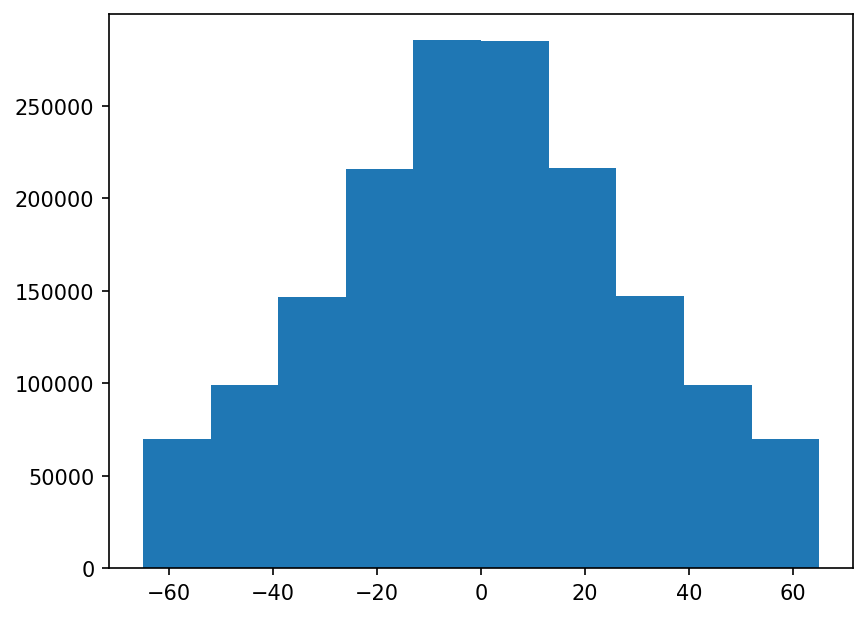

In [6]:
plt.hist(truthSig["z-global"])
plt.show()
# plt.hist(truthBib["z-global"])

In [ ]:
plt.hist2d([])

In [6]:
# clusters_mm = reshapeCluster(recon2Dbib_mm)
# clusters_mp = reshapeCluster(recon2Dbib_mp)
# clusters_sig = reshapeCluster(recon2Dsig)
clustersAll = reshapeCluster(reconDF)

NameError: name 'reconDF' is not defined

-0.019183007067412716
42.05817372628465


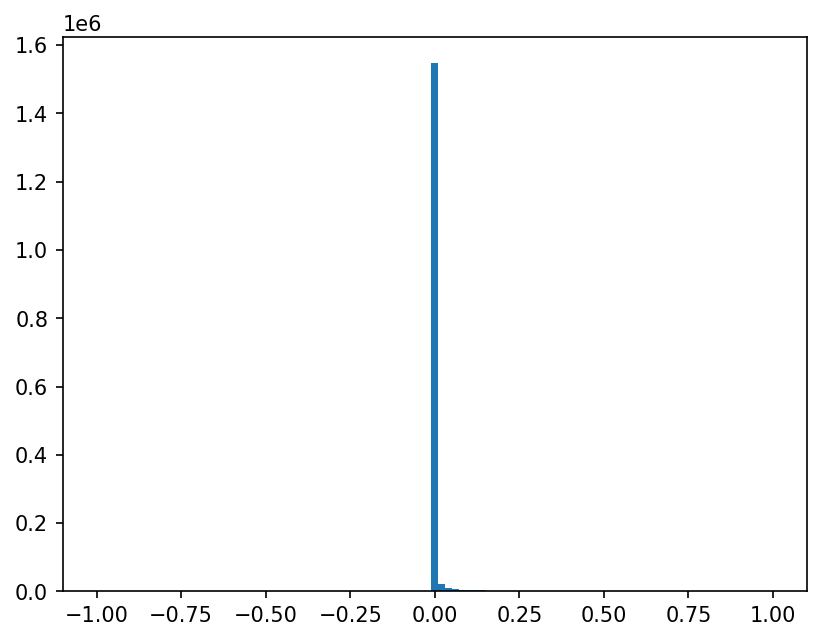

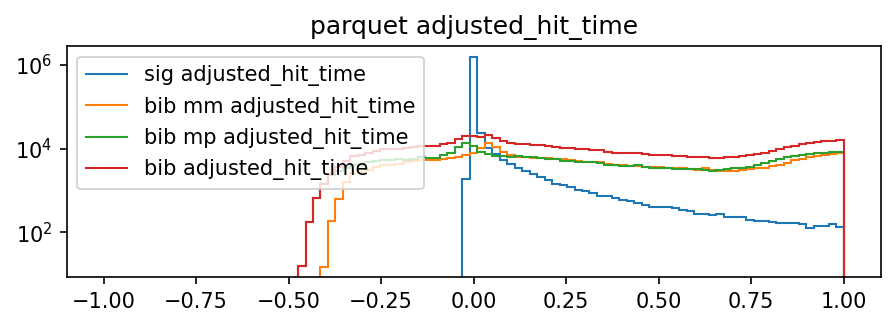

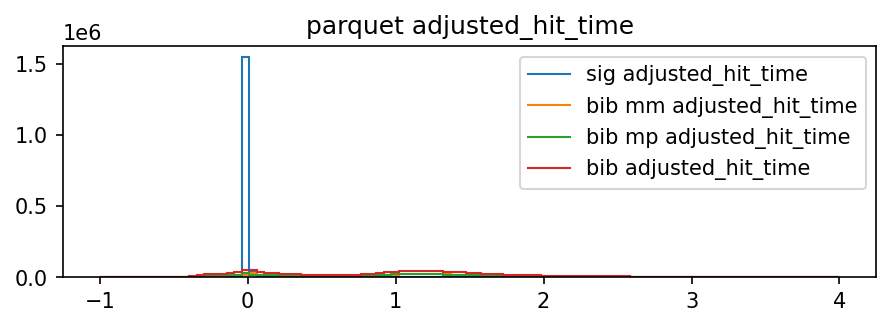

In [7]:
key="adjusted_hit_time"
# key="adjusted_hit_time_30ps_gaussian"
# key="hit_time"
bins=np.linspace(-1,100,100)
bins=np.linspace(-1,1,100)
plt.hist(truthSig[key],bins=bins)
print(np.min(truthSig[key]))
print(np.max(truthSig[key]))
plotManyHisto([truthSig[key],truthBib_mm[key],truthBib_mp[key],truthBib[key]],title=f"parquet {key}",pltLabels=[f"sig {key}",f"bib mm {key}",f"bib mp {key}",f"bib {key}"],bins=bins,showNums=False,figsize=(7,2),yscale='log')
bins=np.linspace(-1,4,100)
plotManyHisto([truthSig[key],truthBib_mm[key],truthBib_mp[key],truthBib[key]],title=f"parquet {key}",pltLabels=[f"sig {key}",f"bib mm {key}",f"bib mp {key}",f"bib {key}"],bins=bins,showNums=False,figsize=(7,2))

#### all histograms


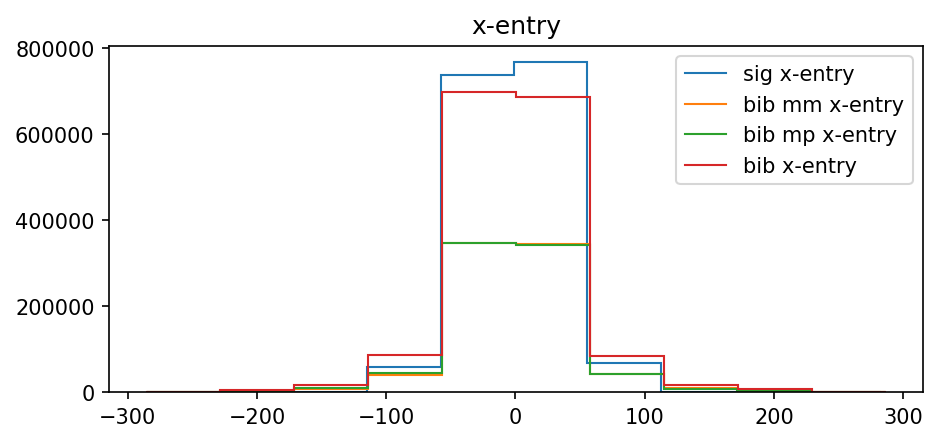

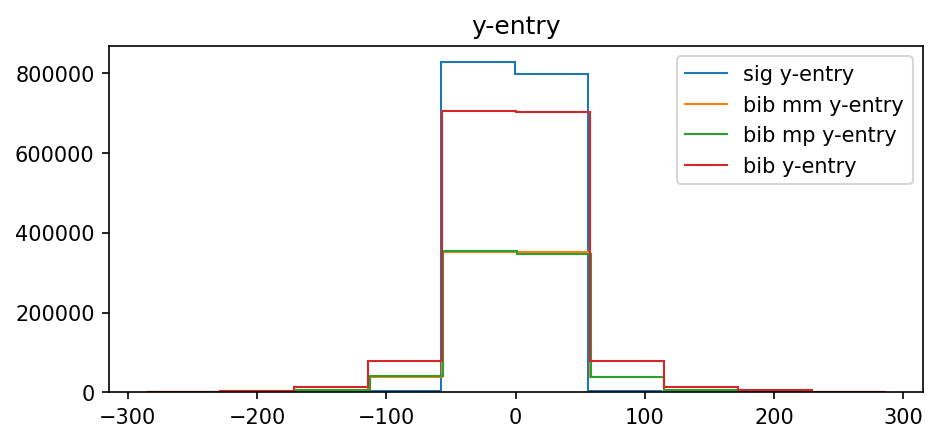

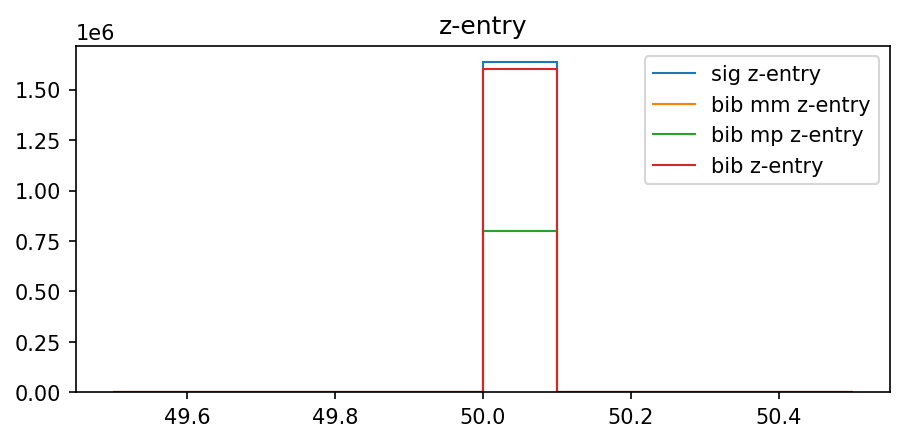

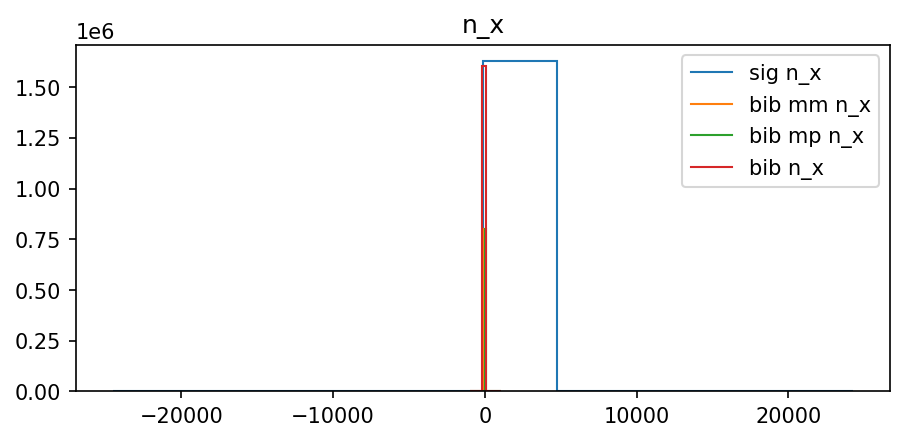

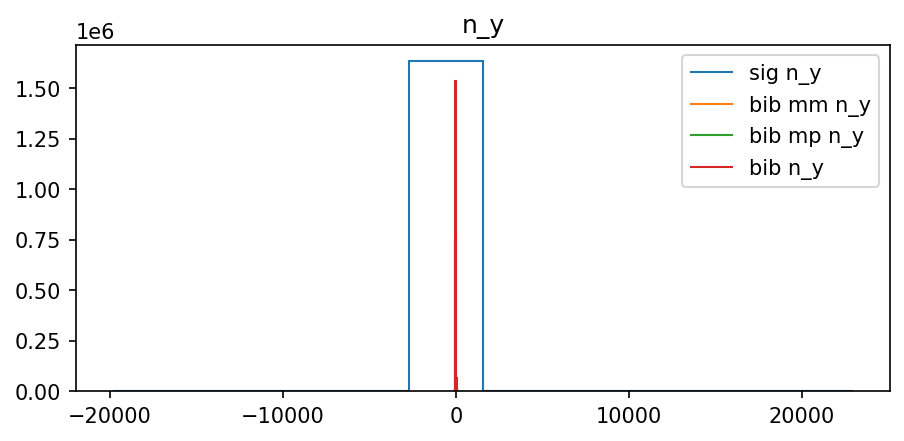

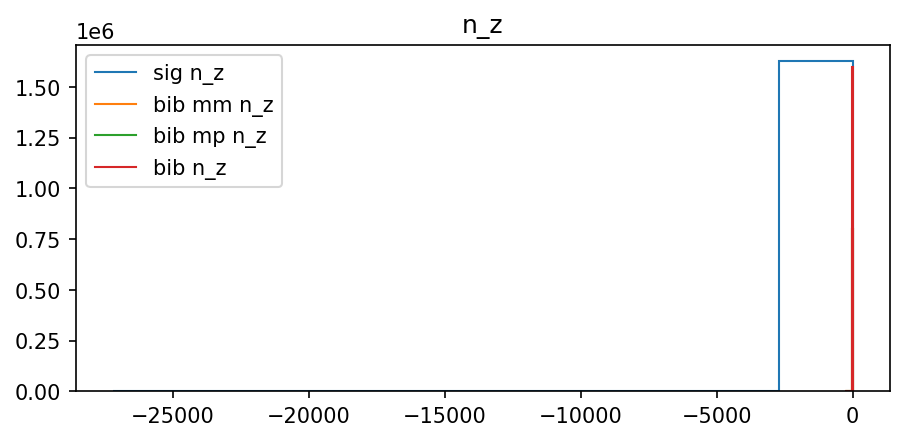

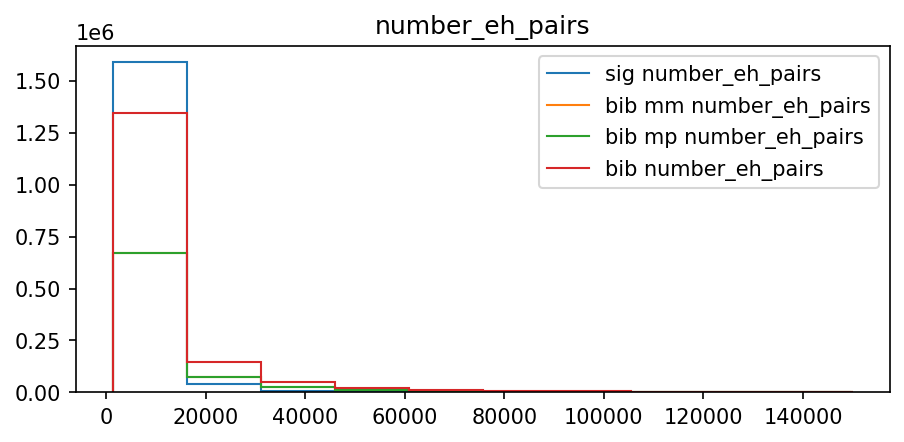

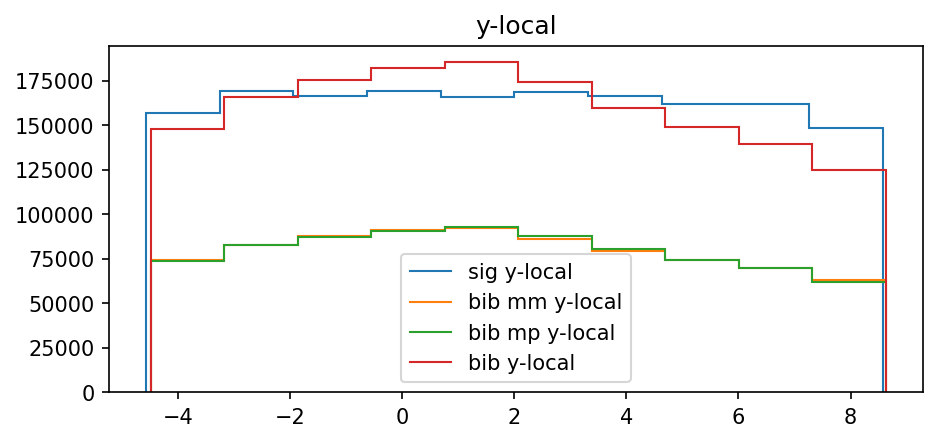

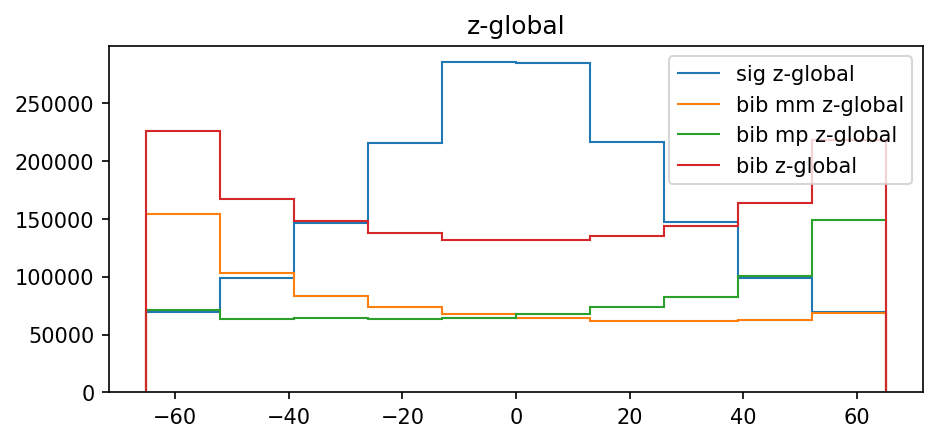

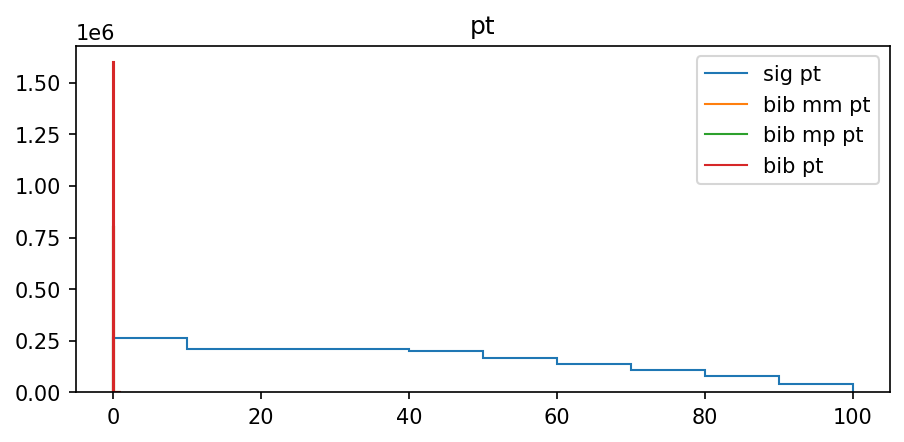

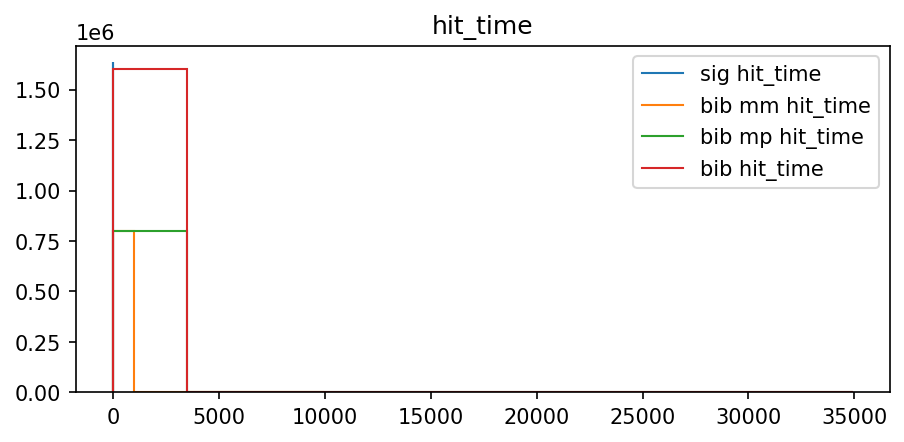

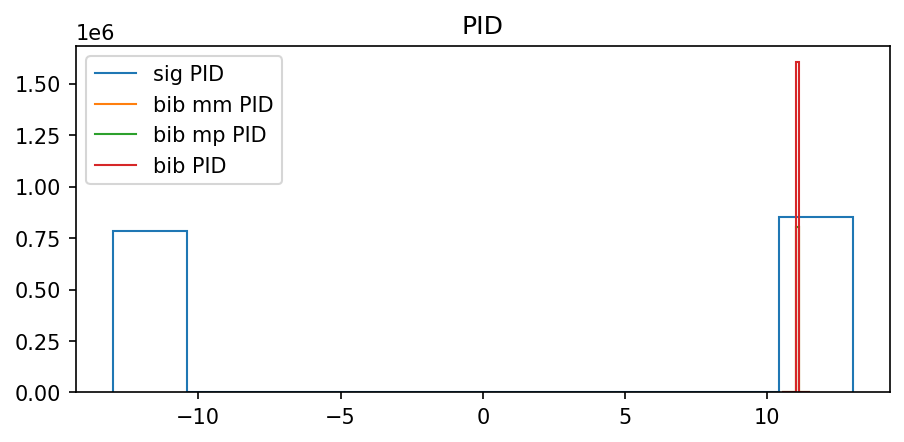

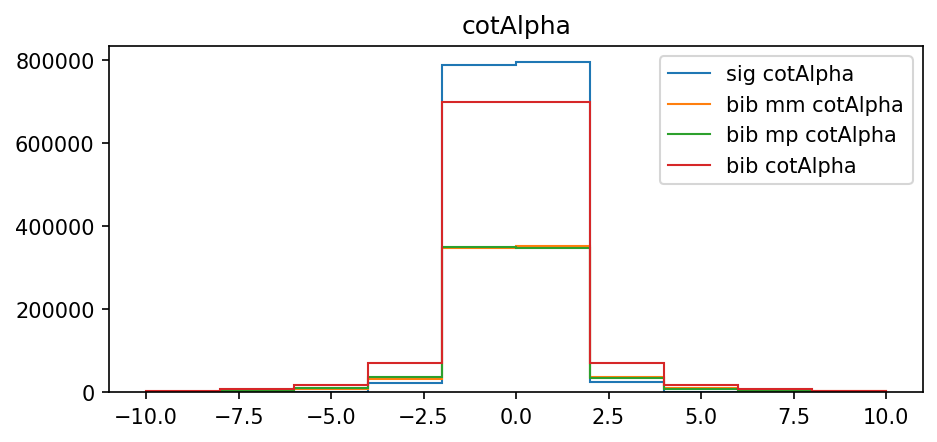

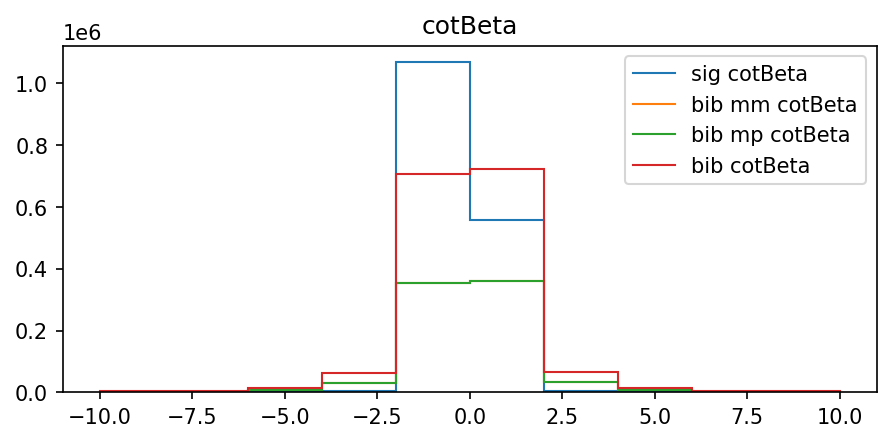

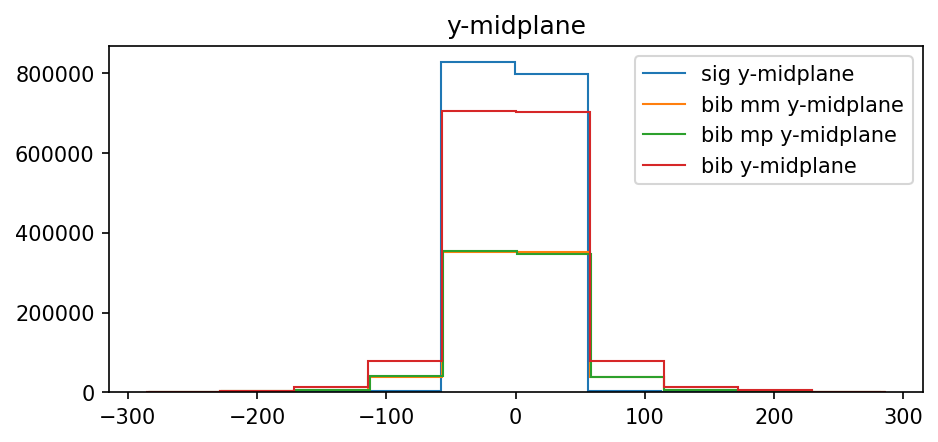

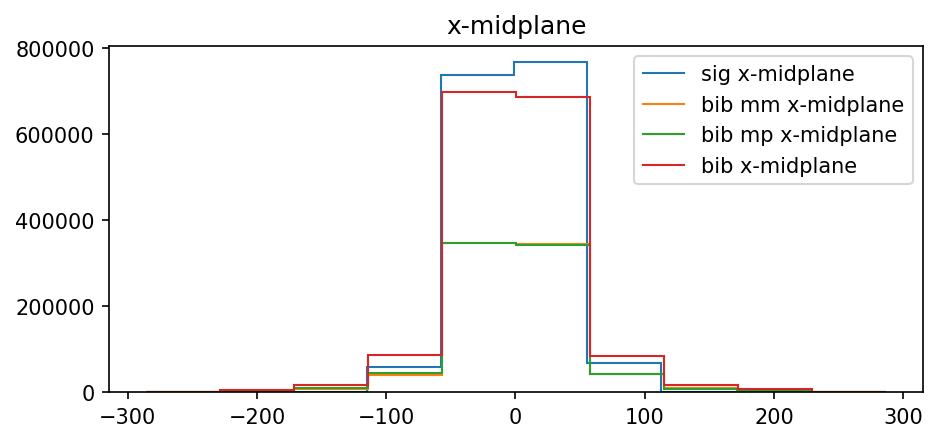

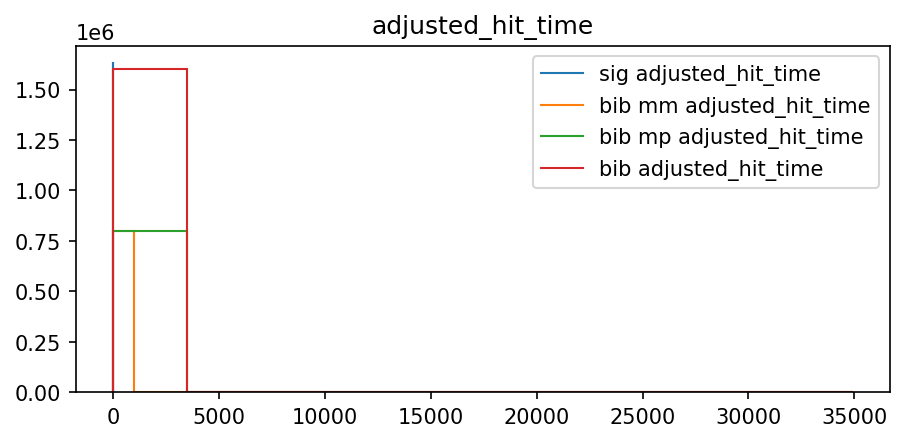

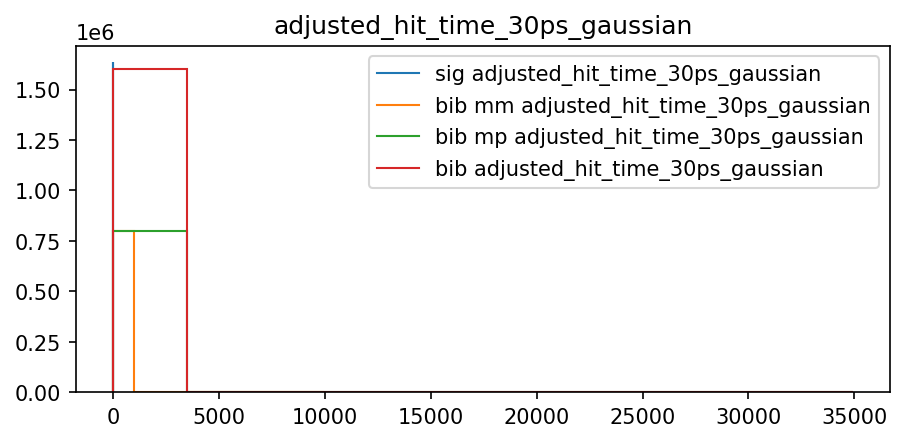

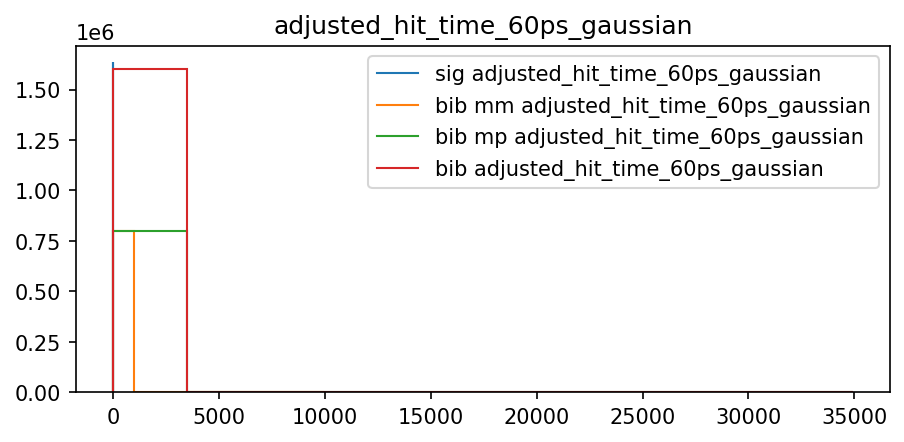

In [9]:
for key in truthDF.keys():
    if key!="source":
        plotManyHisto([truthSig[key],truthBib_mm[key],truthBib_mp[key],truthBib[key]],title=f"{key}",pltLabels=[f"sig {key}",f"bib mm {key}",f"bib mp {key}",f"bib {key}"])
    # plotHisto(title=)
    # plotHisto(title=)

#### now cuts

In [8]:
countBibSig(truthDF,doPrint=True)
print("now with timing cut")
countBibSig(truthDF.query("adjusted_hit_time < 0.02"),doPrint=True)

len truthSig: 1565529
len truthBib: 1603882
len truthBib_mm: 801890
len truthBib_mp: 801992
fraction of total that are MM: 0.2530091553288608
fraction of total that are MP: 0.2530413379646881
fraction of total that are Bib: 0.5060504932935489
fraction of total that are Sig: 0.49394950670645116
now with timing cut
len truthSig: 1190061
len truthBib: 221121
len truthBib_mm: 90493
len truthBib_mp: 130628
fraction of total that are MM: 0.06412567620618743
fraction of total that are MP: 0.09256637343730291
fraction of total that are Bib: 0.15669204964349034
fraction of total that are Sig: 0.8433079503565096


(0.15669204964349034,
 0.8433079503565096,
 0.06412567620618743,
 0.09256637343730291,
 1190061,
 221121,
        x-entry    y-entry  z-entry         n_x        n_y         n_z  \
 0    44.014454  10.323484     50.0  -82.010971  -7.855939  -59.325924   
 1    62.775551 -37.311218     50.0  -82.010361  15.446359  -57.816887   
 2   -14.285469  38.384285     50.0  111.425621  -8.171401  -63.128872   
 4    -4.257314  36.263344     50.0   41.457745 -12.787986  -96.229858   
 5   -33.373436   2.187328     50.0   41.458111  25.009563  -93.798759   
 ..         ...        ...      ...         ...        ...         ...   
 493 -27.679886  -0.307469     50.0  -17.349789  -3.523826  -69.958824   
 494 -15.799657   5.422781     50.0   -1.011363   0.230610   -1.882375   
 496  19.545755  18.151817     50.0   -6.590742  18.523331 -115.424553   
 497   7.742293  -1.868850     50.0   29.343904   0.396400 -128.701324   
 499   6.868886  19.745016     50.0  -72.334465  13.244741  -92.182213   
 
    

In [51]:
fracSigs = []
fracBibs = []
sigKeptFracs = []
bibKeptFracs = []
hitCuts = np.linspace(-0.4,1,100)
hitCuts = np.append(hitCuts,(np.logspace(1,2,10)))
# for cut in hitCuts:
#     fracBib, fracSig, _, _, = countBibSig(truthDF.query("adjusted_hit_time < @cut"),doPrint=False)
#     fracSigs.append(fracSig)
#     fracBibs.append(fracBib)
#alternative provided by google ai for the above lines of code
results = [countBibSig(truthDF.query("adjusted_hit_time < @cut"), doPrint=False) for cut in hitCuts]


In [52]:
fracBibs = np.array([result[0] for result in results])
fracSigs = np.array([result[1] for result in results])
numSigs = np.array([result[4] for result in results])
numBibs = np.array([result[5] for result in results])
sigKeptFracs = numSigs / numTotalSig
bibKeptFracs = numBibs / numTotalBib

#based on https://en.wikipedia.org/wiki/Receiver_operating_characteristic 
#the tpr is (# in the region that are signal) / #total that are signal
#the fpr is (# in the region that are bib) / #total that are bib
tpr = sigKeptFracs
fpr = bibKeptFracs


sigEffic = sigKeptFracs #number of signal in region / total number of signal
backRej = 1-bibKeptFracs#(total bib - numBibs) / total bibs

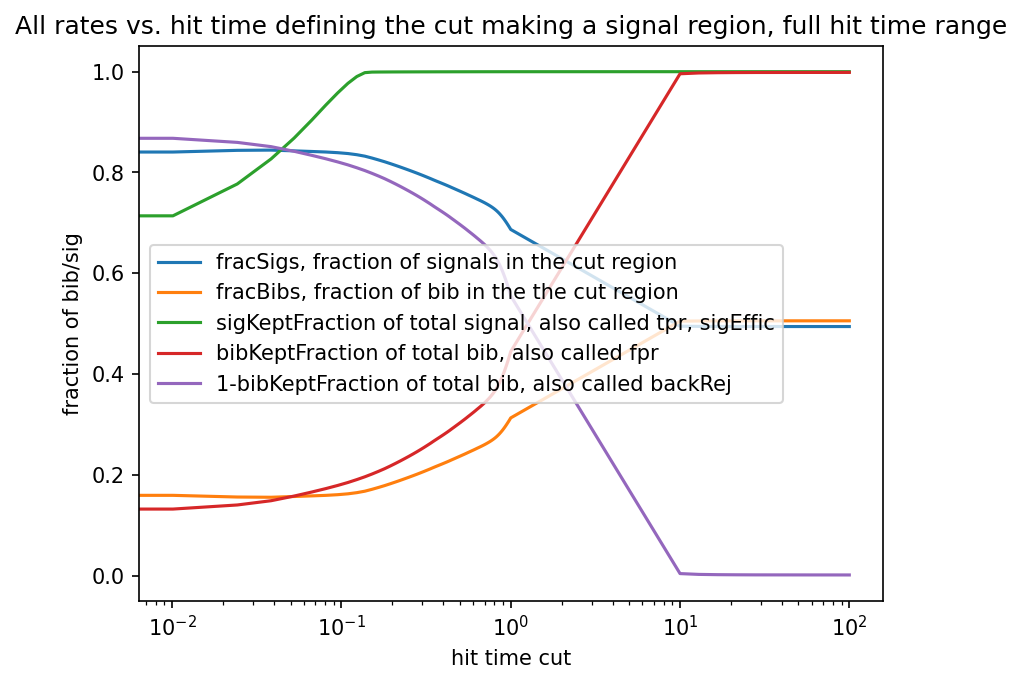

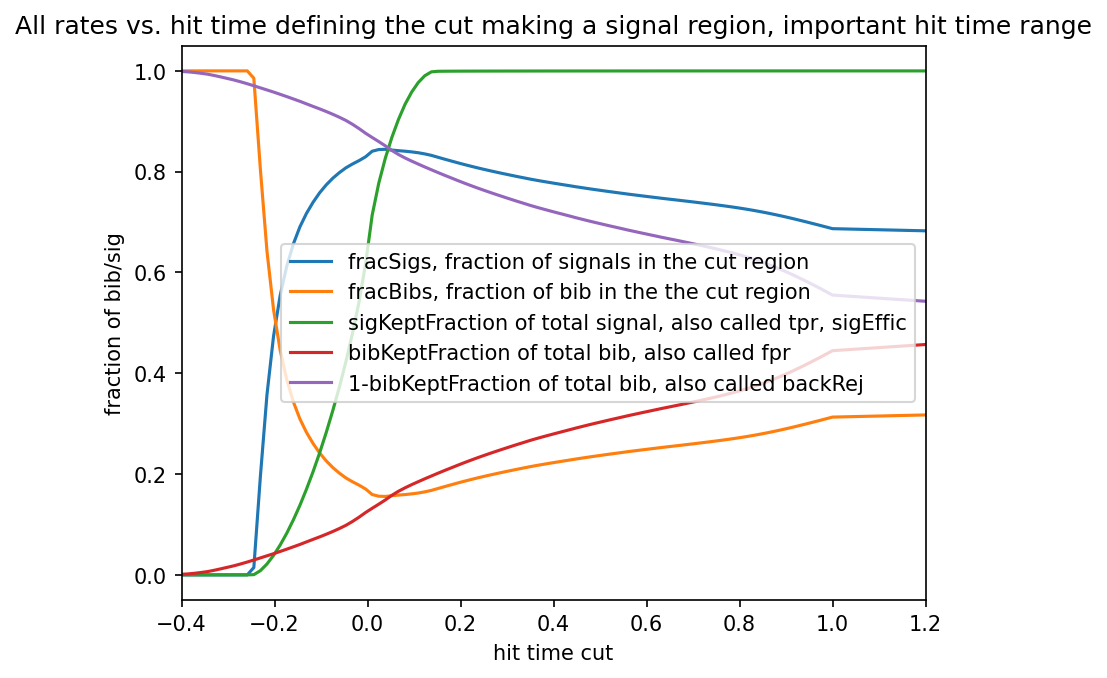

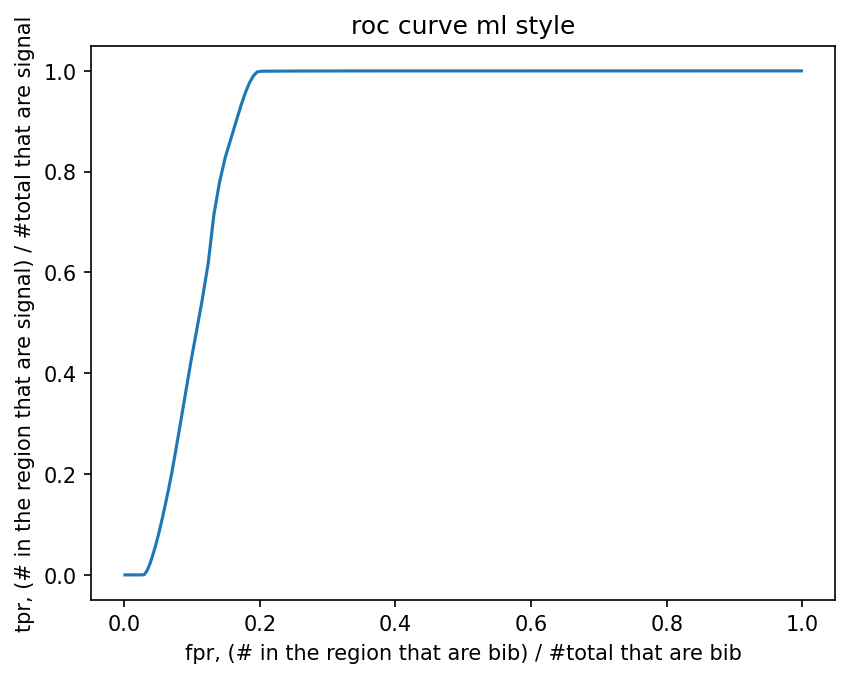

Text(0.5, 0, 'backRej, (# total bib - #in the region that are bib) / #total that are bib')

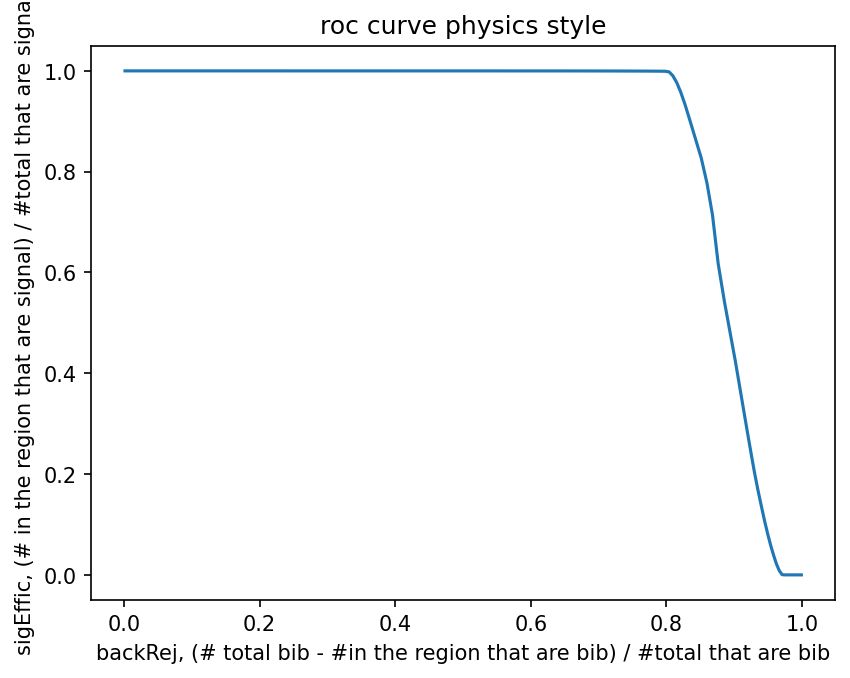

In [59]:
plt.plot(hitCuts,fracSigs,label="fracSigs, fraction of signals in the cut region")
plt.plot(hitCuts,fracBibs,label="fracBibs, fraction of bib in the the cut region")
plt.plot(hitCuts,sigKeptFracs,label="sigKeptFraction of total signal, also called tpr, sigEffic")
plt.plot(hitCuts,bibKeptFracs,label="bibKeptFraction of total bib, also called fpr")
plt.plot(hitCuts,backRej,label="1-bibKeptFraction of total bib, also called backRej")
plt.xlabel("hit time cut")
plt.ylabel("fraction of bib/sig")
plt.legend()
plt.xscale('log')
plt.title("All rates vs. hit time defining the cut making a signal region, full hit time range")
plt.show()
plt.plot(hitCuts,fracSigs,label="fracSigs, fraction of signals in the cut region")
plt.plot(hitCuts,fracBibs,label="fracBibs, fraction of bib in the the cut region")
plt.plot(hitCuts,sigKeptFracs,label="sigKeptFraction of total signal, also called tpr, sigEffic")
plt.plot(hitCuts,bibKeptFracs,label="bibKeptFraction of total bib, also called fpr")
plt.plot(hitCuts,backRej,label="1-bibKeptFraction of total bib, also called backRej")
plt.xlabel("hit time cut")
plt.ylabel("fraction of bib/sig")
plt.title("All rates vs. hit time defining the cut making a signal region, important hit time range")
plt.legend()
plt.xscale('linear')
plt.xlim([-0.4,1.2])
plt.show()
plt.plot(fpr,tpr)
plt.title("roc curve ml style")
plt.ylabel("tpr, (# in the region that are signal) / #total that are signal")
plt.xlabel("fpr, (# in the region that are bib) / #total that are bib")
plt.show()
plt.plot(backRej,sigEffic)
plt.title("roc curve physics style")
plt.ylabel("sigEffic, (# in the region that are signal) / #total that are signal")
plt.xlabel("backRej, (# total bib - #in the region that are bib) / #total that are bib")

In [18]:
countBibSig(truthDF,doPrint=True)
results1 = [countBibSig(truthDF.query("adjusted_hit_time < 5 and adjusted_hit_time > -0.5"),doPrint=True)]
results2 = [countBibSig(truthDF.query("adjusted_hit_time < 0.15 and adjusted_hit_time > -0.09"),doPrint=True)]

fracBibs = np.array([result[0] for result in results1])
fracSigs = np.array([result[1] for result in results1])
numSigs = np.array([result[4] for result in results1])
numBibs = np.array([result[5] for result in results1])
sigKeptFracs = numSigs / numTotalSig
bibKeptFracs = numBibs / numTotalBib
print(sigKeptFracs)
print(bibKeptFracs)
fracBibs = np.array([result[0] for result in results2])
fracSigs = np.array([result[1] for result in results2])
numSigs = np.array([result[4] for result in results2])
numBibs = np.array([result[5] for result in results2])
sigKeptFracs = numSigs / numTotalSig
bibKeptFracs = numBibs / numTotalBib
print(sigKeptFracs)
print(bibKeptFracs)

len truthSig: 1565529
len truthBib: 1603882
len truthBib_mm: 801890
len truthBib_mp: 801992
fraction of total that are MM: 0.2530091553288608
fraction of total that are MP: 0.2530413379646881
fraction of total that are Bib: 0.5060504932935489
fraction of total that are Sig: 0.49394950670645116
len truthSig: 1565526
len truthBib: 1567889
len truthBib_mm: 782257
len truthBib_mp: 785632
fraction of total that are MM: 0.24964998252705115
fraction of total that are MP: 0.25072708211328537
fraction of total that are Bib: 0.5003770646403365
fraction of total that are Sig: 0.4996229353596635
len truthSig: 1127804
len truthBib: 194116
len truthBib_mm: 94825
len truthBib_mp: 99291
fraction of total that are MM: 0.07173278261922053
fraction of total that are MP: 0.07511120188816267
fraction of total that are Bib: 0.1468439845073832
fraction of total that are Sig: 0.8531560154926168
[0.99999808]
[0.97755882]
[0.72039803]
[0.12102885]
